In [34]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os

In [35]:
load_dotenv()

True

In [36]:
# os.environ['OPENAI_API_KEY'] = ""

In [37]:
model = ChatOpenAI(model='gpt-4o-mini')

In [38]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", 'negative'] = Field(description='Sentiment of the review')

In [39]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [40]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [41]:
prompt = "What is the sentiment of the following review - The software is too good"

structured_model.invoke(prompt).sentiment

'positive'

# Define the State and start building workflow.

In [42]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [43]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state['review']}'

    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

In [44]:
# Function for the condition workflow.

def check_sentiment(state: ReviewState) -> Literal['positive_response', 'run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return "run_diagnosis"

def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}


def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
    """
    response = structured_model2.invoke(prompt)

    # model_dump() is used for the converting the pydantic object to the dictionary.
    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response = model.invoke(prompt).content

    return {'response': response}

In [45]:
# Initialize the Graph.
graph = StateGraph(ReviewState)

# Add the Nodes.
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('positive_response', positive_response)
graph.add_node('negative_response', negative_response)

# Add the edges.
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)


workflow = graph.compile()

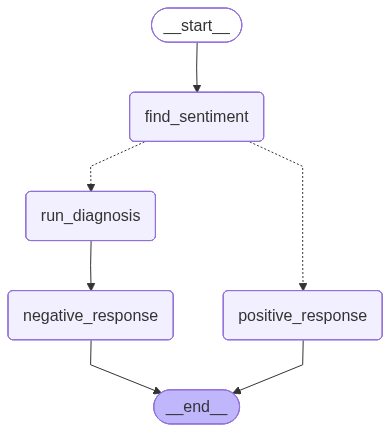

In [46]:
workflow

In [48]:
initial_state = {
    'review': "I'm interested into the HFT arbitrage and ICT concepts but not able to master it"
}

workflow.invoke(initial_state)

{'review': "I'm interested into the HFT arbitrage and ICT concepts but not able to master it",
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Other',
  'tone': 'frustrated',
  'urgency': 'medium'},
 'response': "Subject: We're Here to Help!\n\nHi [User's Name],\n\nI understand that you're dealing with an issue that’s been frustrating for you, and I'm genuinely sorry to hear that. Your time and experience are valuable, and I appreciate your patience as we work through this together.\n\nCould you please provide more details about the issue you're facing? Any specific information you can share will help me assist you more effectively. Rest assured, I’m here to help you find a resolution as quickly as possible.\n\nThank you for reaching out, and I look forward to hearing from you soon!\n\nWarm regards,\n\n[Your Name]  \n[Your Position]  \n[Company Name]  \n[Contact Information]"}

In [ ]:
 n